<a href="https://colab.research.google.com/github/jaysonDfernandez/DataScience1/blob/main/MiniProject2DE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#upload the MP2_Data.csv dataset
from google.colab import files
uploaded = files.upload()

Saving MP2_Data.csv to MP2_Data (2).csv


In [ ]:
#read the csv file
import io
pd.options.display.max_columns = 50
data=pd.read_csv(io.BytesIO(uploaded['MP2_Data.csv']))
data.head()

,ID,Week2_Quiz1,Week3_MP1,Week3_PR1,Week5_MP2,Week5_PR2,Week7_MP3,Week7_PR3,Week4_Quiz2,Week6_Quiz3,Week8_Total,Week1_Stat0,Week1_Stat1,Week1_Stat2,Week1_Stat3,Week2_Stat0,Week2_Stat1,Week2_Stat2,Week2_Stat3,Week3_Stat0,Week3_Stat1,Week3_Stat2,Week3_Stat3,Week4_Stat0,Week4_Stat1,Week4_Stat2,Week4_Stat3,Week5_Stat0,Week5_Stat1,Week5_Stat2,Week5_Stat3,Week6_Stat0,Week6_Stat1,Week6_Stat2,Week6_Stat3,Week7_Stat0,Week7_Stat1,Week7_Stat2,Week7_Stat3,Week8_Stat0,Week8_Stat1,Week8_Stat2,Week8_Stat3,Week9_Stat0,Week9_Stat1,Week9_Stat2,Week9_Stat3,Grade
0,ML-2020-1,5.00,15.0,5.0,16.09,5.00,21.88,5.0,5.00,5.0,82.97,0,0,0,0,7,30,1,0,30,4,0,0,14,39,2,0,24,6,1,0,28,30,2,0,2,0,1,0,5,4,0,4,8,6,1,0,4
1,ML-2020-2,3.33,15.0,5.0,17.83,5.00,22.27,5.0,4.00,5.0,82.43,8,0,0,0,61,10,3,8,100,4,4,3,130,16,1,4,48,19,5,5,57,22,2,4,31,9,0,8,5,2,0,0,25,3,2,5,4
2,ML-2020-3,1.67,13.0,5.0,15.22,5.00,27.05,2.5,5.00,5.0,79.44,4,0,0,0,19,10,3,3,25,4,0,2,50,19,2,2,28,6,0,2,14,20,2,0,12,4,0,0,8,2,0,0,9,0,1,0,3
3,ML-2020-4,2.50,14.0,5.0,10.00,5.00,31.02,5.0,3.13,5.0,80.65,12,0,0,1,30,10,1,6,79,4,2,2,240,27,2,1,47,4,3,1,99,19,4,0,29,4,5,4,10,0,0,0,7,6,0,0,3
4,ML-2020-6,0.00,15.0,5.0,12.17,4.93,15.91,5.0,4.67,5.0,67.68,6,0,0,0,0,0,0,0,27,5,0,0,6,15,1,0,32,12,0,8,22,18,1,2,43,4,3,6,8,5,1,1,5,3,1,0,2


In [ ]:
#check if there are any missing values
data.isnull().sum()

ID             0
Week2_Quiz1    0
Week3_MP1      0
Week3_PR1      0
Week5_MP2      0
Week5_PR2      0
Week7_MP3      0
Week7_PR3      0
Week4_Quiz2    0
Week6_Quiz3    0
Week8_Total    0
Week1_Stat0    0
Week1_Stat1    0
Week1_Stat2    0
Week1_Stat3    0
Week2_Stat0    0
Week2_Stat1    0
Week2_Stat2    0
Week2_Stat3    0
Week3_Stat0    0
Week3_Stat1    0
Week3_Stat2    0
Week3_Stat3    0
Week4_Stat0    0
Week4_Stat1    0
Week4_Stat2    0
Week4_Stat3    0
Week5_Stat0    0
Week5_Stat1    0
Week5_Stat2    0
Week5_Stat3    0
Week6_Stat0    0
Week6_Stat1    0
Week6_Stat2    0
Week6_Stat3    0
Week7_Stat0    0
Week7_Stat1    0
Week7_Stat2    0
Week7_Stat3    0
Week8_Stat0    0
Week8_Stat1    0
Week8_Stat2    0
Week8_Stat3    0
Week9_Stat0    0
Week9_Stat1    0
Week9_Stat2    0
Week9_Stat3    0
Grade          0
dtype: int64

In [ ]:
#drop ID and total score
data.drop('ID', axis = 1, inplace = True)
data.drop(data.columns[9], axis=1, inplace=True)

#optional: drop all features that don't give points to the overall grade (remove '#' to drop the features)
#data.drop(data.columns[9:-1], axis=1, inplace=True)
data.head()

,Week2_Quiz1,Week3_MP1,Week3_PR1,Week5_MP2,Week5_PR2,Week7_MP3,Week7_PR3,Week4_Quiz2,Week6_Quiz3,Week1_Stat0,Week1_Stat1,Week1_Stat2,Week1_Stat3,Week2_Stat0,Week2_Stat1,Week2_Stat2,Week2_Stat3,Week3_Stat0,Week3_Stat1,Week3_Stat2,Week3_Stat3,Week4_Stat0,Week4_Stat1,Week4_Stat2,Week4_Stat3,Week5_Stat0,Week5_Stat1,Week5_Stat2,Week5_Stat3,Week6_Stat0,Week6_Stat1,Week6_Stat2,Week6_Stat3,Week7_Stat0,Week7_Stat1,Week7_Stat2,Week7_Stat3,Week8_Stat0,Week8_Stat1,Week8_Stat2,Week8_Stat3,Week9_Stat0,Week9_Stat1,Week9_Stat2,Week9_Stat3,Grade
0,5.00,15.0,5.0,16.09,5.00,21.88,5.0,5.00,5.0,0,0,0,0,7,30,1,0,30,4,0,0,14,39,2,0,24,6,1,0,28,30,2,0,2,0,1,0,5,4,0,4,8,6,1,0,4
1,3.33,15.0,5.0,17.83,5.00,22.27,5.0,4.00,5.0,8,0,0,0,61,10,3,8,100,4,4,3,130,16,1,4,48,19,5,5,57,22,2,4,31,9,0,8,5,2,0,0,25,3,2,5,4
2,1.67,13.0,5.0,15.22,5.00,27.05,2.5,5.00,5.0,4,0,0,0,19,10,3,3,25,4,0,2,50,19,2,2,28,6,0,2,14,20,2,0,12,4,0,0,8,2,0,0,9,0,1,0,3
3,2.50,14.0,5.0,10.00,5.00,31.02,5.0,3.13,5.0,12,0,0,1,30,10,1,6,79,4,2,2,240,27,2,1,47,4,3,1,99,19,4,0,29,4,5,4,10,0,0,0,7,6,0,0,3
4,0.00,15.0,5.0,12.17,4.93,15.91,5.0,4.67,5.0,6,0,0,0,0,0,0,0,27,5,0,0,6,15,1,0,32,12,0,8,22,18,1,2,43,4,3,6,8,5,1,1,5,3,1,0,2


In [ ]:
#devide into training and test sets
data['isTrain'] = np.random.uniform(0, 1, len(data)) <= .75

In [ ]:
data.head()

,Week2_Quiz1,Week3_MP1,Week3_PR1,Week5_MP2,Week5_PR2,Week7_MP3,Week7_PR3,Week4_Quiz2,Week6_Quiz3,Week1_Stat0,Week1_Stat1,Week1_Stat2,Week1_Stat3,Week2_Stat0,Week2_Stat1,Week2_Stat2,Week2_Stat3,Week3_Stat0,Week3_Stat1,Week3_Stat2,Week3_Stat3,Week4_Stat0,Week4_Stat1,Week4_Stat2,Week4_Stat3,Week5_Stat0,Week5_Stat1,Week5_Stat2,Week5_Stat3,Week6_Stat0,Week6_Stat1,Week6_Stat2,Week6_Stat3,Week7_Stat0,Week7_Stat1,Week7_Stat2,Week7_Stat3,Week8_Stat0,Week8_Stat1,Week8_Stat2,Week8_Stat3,Week9_Stat0,Week9_Stat1,Week9_Stat2,Week9_Stat3,Grade,isTrain
0,5.00,15.0,5.0,16.09,5.00,21.88,5.0,5.00,5.0,0,0,0,0,7,30,1,0,30,4,0,0,14,39,2,0,24,6,1,0,28,30,2,0,2,0,1,0,5,4,0,4,8,6,1,0,4,True
1,3.33,15.0,5.0,17.83,5.00,22.27,5.0,4.00,5.0,8,0,0,0,61,10,3,8,100,4,4,3,130,16,1,4,48,19,5,5,57,22,2,4,31,9,0,8,5,2,0,0,25,3,2,5,4,True
2,1.67,13.0,5.0,15.22,5.00,27.05,2.5,5.00,5.0,4,0,0,0,19,10,3,3,25,4,0,2,50,19,2,2,28,6,0,2,14,20,2,0,12,4,0,0,8,2,0,0,9,0,1,0,3,True
3,2.50,14.0,5.0,10.00,5.00,31.02,5.0,3.13,5.0,12,0,0,1,30,10,1,6,79,4,2,2,240,27,2,1,47,4,3,1,99,19,4,0,29,4,5,4,10,0,0,0,7,6,0,0,3,False
4,0.00,15.0,5.0,12.17,4.93,15.91,5.0,4.67,5.0,6,0,0,0,0,0,0,0,27,5,0,0,6,15,1,0,32,12,0,8,22,18,1,2,43,4,3,6,8,5,1,1,5,3,1,0,2,True


In [ ]:
train = data[data['isTrain']==True]
test = data[data['isTrain']==False]

In [ ]:
print('Amount of training datapoints:', len(train))
print('Amount of testing datapoints:', len(test))

Amount of training datapoints: 78
Amount of testing datapoints: 29


In [ ]:
features = data.columns[:-2]
features

Index(['Week2_Quiz1', 'Week3_MP1', 'Week3_PR1', 'Week5_MP2', 'Week5_PR2',
       'Week7_MP3', 'Week7_PR3', 'Week4_Quiz2', 'Week6_Quiz3', 'Week1_Stat0',
       'Week1_Stat1', 'Week1_Stat2', 'Week1_Stat3', 'Week2_Stat0',
       'Week2_Stat1', 'Week2_Stat2', 'Week2_Stat3', 'Week3_Stat0',
       'Week3_Stat1', 'Week3_Stat2', 'Week3_Stat3', 'Week4_Stat0',
       'Week4_Stat1', 'Week4_Stat2', 'Week4_Stat3', 'Week5_Stat0',
       'Week5_Stat1', 'Week5_Stat2', 'Week5_Stat3', 'Week6_Stat0',
       'Week6_Stat1', 'Week6_Stat2', 'Week6_Stat3', 'Week7_Stat0',
       'Week7_Stat1', 'Week7_Stat2', 'Week7_Stat3', 'Week8_Stat0',
       'Week8_Stat1', 'Week8_Stat2', 'Week8_Stat3', 'Week9_Stat0',
       'Week9_Stat1', 'Week9_Stat2', 'Week9_Stat3'],
      dtype='object')

# **Random forest**

In [ ]:
clf = RandomForestClassifier(n_jobs=2, random_state=0)
clf.fit(train[features], train['Grade'])

RandomForestClassifier(n_jobs=2, random_state=0)

In [ ]:
predictions = clf.predict(test[features])

In [ ]:
clf.predict_proba(test[features])

array([[0.02, 0.07, 0.39, 0.36, 0.16],
       [1.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.02, 0.45, 0.31, 0.22],
       [0.99, 0.  , 0.  , 0.  , 0.01],
       [1.  , 0.  , 0.  , 0.  , 0.  ],
       [0.99, 0.  , 0.01, 0.  , 0.  ],
       [0.98, 0.  , 0.01, 0.  , 0.01],
       [0.12, 0.14, 0.32, 0.22, 0.2 ],
       [1.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.14, 0.42, 0.3 , 0.14],
       [0.12, 0.06, 0.12, 0.42, 0.28],
       [0.1 , 0.14, 0.55, 0.17, 0.04],
       [0.02, 0.02, 0.32, 0.52, 0.12],
       [0.04, 0.07, 0.24, 0.39, 0.26],
       [0.88, 0.04, 0.06, 0.01, 0.01],
       [0.  , 0.02, 0.16, 0.61, 0.21],
       [0.06, 0.07, 0.23, 0.29, 0.35],
       [0.12, 0.2 , 0.21, 0.35, 0.12],
       [0.04, 0.04, 0.12, 0.4 , 0.4 ],
       [0.02, 0.02, 0.21, 0.5 , 0.25],
       [1.  , 0.  , 0.  , 0.  , 0.  ],
       [0.8 , 0.02, 0.1 , 0.06, 0.02],
       [1.  , 0.  , 0.  , 0.  , 0.  ],
       [1.  , 0.  , 0.  , 0.  , 0.  ],
       [1.  , 0.  , 0.  , 0.  , 0.  ],
       [0.89, 0.  , 0.07,

In [ ]:
predictions

array([3, 0, 3, 0, 0, 0, 0, 3, 0, 3, 4, 3, 4, 4, 0, 4, 5, 4, 4, 4, 0, 0,
       0, 0, 0, 0, 0, 0, 0])

In [ ]:
test['Grade']

3      3
6      0
17     4
18     0
32     0
33     0
35     0
37     3
38     0
42     3
47     4
48     2
50     4
55     5
57     0
63     4
66     4
67     3
71     5
73     4
81     0
83     0
86     0
88     0
90     0
91     0
92     0
94     0
102    0
Name: Grade, dtype: int64

In [ ]:
#confusion matrix
pd.crosstab(test['Grade'], predictions, rownames=['Actual grade'], colnames=['Predicted grade'])

Predicted grade,0,3,4,5
Actual grade,,,,
0,16,0,0,0
2,0,1,0,0
3,0,3,1,0
4,0,1,4,1
5,0,0,2,0


<function matplotlib.pyplot.show(*args, **kw)>

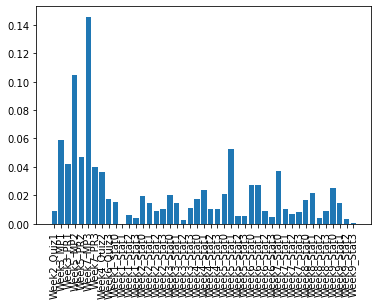

In [ ]:
#plot importance of the features
importanceList = list(zip(train[features], clf.feature_importances_))

importanceList2 = [(elem1, elem2) for elem1, elem2 in importanceList]
plt.bar(*zip(*importanceList2))
plt.xticks(rotation=90)
plt.show

In [ ]:
#check accuracy score
from sklearn.metrics import accuracy_score
print( accuracy_score(test['Grade'], predictions))

0.7931034482758621


# **Logistic regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [ ]:
logRegr = LogisticRegression()

In [ ]:
logRegr.fit(train[features], train['Grade'])

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


LogisticRegression()

In [ ]:
predcts = logRegr.predict(test[features])

In [ ]:
print(predcts)

[3 0 3 0 0 0 0 3 3 3 0 3 3 3 3 4 3 4 5 3 0 3 0 0 0 0 0 0 4]


In [ ]:
#confusion matrix
pd.crosstab(test['Grade'], predcts, rownames=['Actual grade'], colnames=['Predicted grade'])

Predicted grade,0,3,4,5
Actual grade,,,,
0,12,3,1,0
2,0,1,0,0
3,0,3,1,0
4,1,4,1,0
5,0,1,0,1


In [ ]:
#check accuracy score
print( accuracy_score(test['Grade'], predcts))

0.5862068965517241
